# Clase 3: análisis del conjunto de datos

Esta notebook esta basada en el tutorial "SciPy 2021 Tutorial: Fairness in AI systems: From social context to practice using Fairlearn" elaborado por Manojit Nandi, Miroslav Dudík, Triveni Gandhi, Lisa Ibañez, Adrin Jalali, Michael Madaio, Hanna Wallach, Hilde Weerts.

Usaremos el conjunto de datos "Diabetes 130-US Hospitals for Years 1999-2008" la versión original la pueden encontrar en [el repositorio de la UCI](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008).  

## Selección del problema y selección del conjunto de datos:

El problema en el que nos centraremos será en **considerar un sistema automatizado que recomiende pacientes para programas de gestión en la atención de alto riesgo**. El objetivo final es mejorar la atención de pacientes con necesidades medicas complejas. Como se trata de programas costosos, los sistemas de salud acuden a algoritmos que identidiquen a aquellas personas que se beneficiarían mas de recibir el cuidado.

Trabajaremos con un conjunto de datos formado por registros clinicos de un hospital que indican la readmisión de los pacientes durante 1998 y 2008. Pueden encontrar más información [aquí](https://fairlearn.org/main/user_guide/datasets/diabetes_hospital_data.html).
Cada registro representa los registros de ingreso hospitalario de un paciente diagnosticado con diabetes cuya estancia duró de uno a catorce días.
Los atributos que describen cada instancia incluyen datos demográficos, diagnósticos, medicamentos para la diabetes, número de visitas en el año anterior al encuentro e información del pagador, así como si el paciente fue readmitido después del alta y si la readmisión ocurrió dentro de los 30 días posteriores al alta.

El **objetivo será desarrollar un modelo de clasificación que decida si se debe sugerir a los pacientes a sus médicos de atención primaria que se inscriban en el programa de gestión de atención de alto riesgo. La predicción positiva significará la recomendación en el programa de atención**. Se utilizará la variable *readmission within 30 days* como target.


In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/fairlearn/talks/main/2021_scipy_tutorial/data/diabetic_preprocessed.csv")
df.head()

,race,gender,age,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,...,change,diabetesMed,medicare,medicaid,had_emergency,had_inpatient_days,had_outpatient_days,readmitted,readmit_binary,readmit_30_days
0,Caucasian,Female,30 years or younger,Other,Referral,1,Other,41,0,1,...,No,No,False,False,False,False,False,NO,0,0
1,Caucasian,Female,30 years or younger,Discharged to Home,Emergency,3,Missing,59,0,18,...,Ch,Yes,False,False,False,False,False,>30,1,0
2,AfricanAmerican,Female,30 years or younger,Discharged to Home,Emergency,2,Missing,11,5,13,...,No,Yes,False,False,False,True,True,NO,0,0
3,Caucasian,Male,30-60 years,Discharged to Home,Emergency,2,Missing,44,1,16,...,Ch,Yes,False,False,False,False,False,NO,0,0
4,Caucasian,Male,30-60 years,Discharged to Home,Emergency,1,Missing,51,0,8,...,Ch,Yes,False,False,False,False,False,NO,0,0


Descripción de las columnas https://fairlearn.org/v0.12/user_guide/datasets/diabetes_hospital_data.html

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      101766 non-null  object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   discharge_disposition_id  101766 non-null  object
 4   admission_source_id       101766 non-null  object
 5   time_in_hospital          101766 non-null  int64 
 6   medical_specialty         101766 non-null  object
 7   num_lab_procedures        101766 non-null  int64 
 8   num_procedures            101766 non-null  int64 
 9   num_medications           101766 non-null  int64 
 10  primary_diagnosis         101766 non-null  object
 11  number_diagnoses          101766 non-null  int64 
 12  max_glu_serum             5346 non-null    object
 13  A1Cresult                 17018 non-null   object
 14  insu

In [ ]:
# Ver el detalle de las categorías
categorical_values = {}
for col in df:
  if col not in {'time_in_hospital', 'num_lab_procedures',
                 'num_procedures', 'num_medications', 'number_diagnoses'}:
    categorical_values[col] = pd.Series(df[col].value_counts().index.values)
categorical_values_df = pd.DataFrame(categorical_values).fillna('')
categorical_values_df.T

,0,1,2,3,4,5
race,Caucasian,AfricanAmerican,Unknown,Hispanic,Other,Asian
gender,Female,Male,Unknown/Invalid,,,
age,Over 60 years,30-60 years,30 years or younger,,,
discharge_disposition_id,Discharged to Home,Other,,,,
admission_source_id,Emergency,Referral,Other,,,
medical_specialty,Missing,Other,InternalMedicine,Emergency/Trauma,Family/GeneralPractice,Cardiology
primary_diagnosis,Other,Respiratory Issues,Diabetes,Genitourinary Issues,Musculoskeletal Issues,
max_glu_serum,Norm,>200,>300,,,
A1Cresult,>8,Norm,>7,,,
insulin,No,Steady,Down,Up,,


In [ ]:
# le asigno el tipo "categoría" a los atributos categóricos
categorical_features = [
    "race",
    "gender",
    "age",
    "discharge_disposition_id",
    "admission_source_id",
    "medical_specialty",
    "primary_diagnosis",
    "max_glu_serum",
    "A1Cresult",
    "insulin",
    "change",
    "diabetesMed",
    "readmitted"
]

for col_name in categorical_features:
  df[col_name] = df[col_name].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   race                      101766 non-null  category
 1   gender                    101766 non-null  category
 2   age                       101766 non-null  category
 3   discharge_disposition_id  101766 non-null  category
 4   admission_source_id       101766 non-null  category
 5   time_in_hospital          101766 non-null  int64   
 6   medical_specialty         101766 non-null  category
 7   num_lab_procedures        101766 non-null  int64   
 8   num_procedures            101766 non-null  int64   
 9   num_medications           101766 non-null  int64   
 10  primary_diagnosis         101766 non-null  category
 11  number_diagnoses          101766 non-null  int64   
 12  max_glu_serum             5346 non-null    category
 13  A1Cresult                 170

In [ ]:
# Descripción estadística de los atributos numéricos

df.describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,readmit_binary,readmit_30_days
count,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,4.395987,43.095641,1.339730,16.021844,7.422607,0.460881,0.111599
std,2.985108,19.674362,1.705807,8.127566,1.933600,0.498470,0.314874
min,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,2.000000,31.000000,0.000000,10.000000,6.000000,0.000000,0.000000
50%,4.000000,44.000000,1.000000,15.000000,8.000000,0.000000,0.000000
75%,6.000000,57.000000,2.000000,20.000000,9.000000,1.000000,0.000000
max,14.000000,132.000000,6.000000,81.000000,16.000000,1.000000,1.000000


# Analisis del conjunto de datos en busca de una variedad de problemas que podrían desencadenar en inequidad

Por lo general, existen características legalmente identificadas que prohíben la discriminación, y suelen ser estas características las que se consideran atributos "protegidos" o "sensibles" en la literatura informática. Cuando hablamos acerca de la Ly de Datos Personales de Argentina, se presenta una lista de algunos de estos atributos protegidos: género, etnia, afiliación sindical, etc.
 [Mehrabi 2019]

En lo que sigue nos referiremos informalmente como un atributo sensible es cualquier variable en la que se desea cierta noción de equidad. En general, se asume implícitamente que los atributos sensibles son binarios o categóricos.

Observación
No existe una definición ampliamente aceptada y matemáticamente rigurosa de un atributo sensible. Su definición proviene de la legislación antidiscriminatoria (en el contexto estadounidense, donde se denomina clase protegida4), pero generalmente se ignora.
https://trentonchang.org/files/lecture_15.pdf

## 1. Tamaño de la muestra de los distintos grupos demográficos

Para este estudio utilizaremos el criterio de **group fairness**: consideran que un modelo es justo si sus predicciones son igualmente precisas en un conjunto predefinido de grupos.

En lo relativo a *fairness* los grupos con pocas muestras podrían tener inconvenientes en la evaluación (los impactos del sistema de IA en grupos más pequeños son más difíciles de evaluar, porque debido a que hay menos puntos de datos, tenemos una incertidumbre mucho mayor (barras de error) en nuestras estimaciones) y en el entrenamiento (menos puntos de datos de entrenamiento significan que nuestro modelo no logra capturar adecuadamente ningún patrón de datos específico para grupos más pequeños, lo que significa que sus predicciones en estos grupos podría ser peores).

A continuación analizamos el tamaño de las muestras de los subgrupos de acuerdo a "raza", "genero" y "edad":

In [ ]:
df["race"].value_counts()

,count
race,
Caucasian,76099
AfricanAmerican,19210
Unknown,2273
Hispanic,2037
Other,1506
Asian,641


In [ ]:
df["race"].value_counts(normalize=True)

,proportion
race,
Caucasian,0.747784
AfricanAmerican,0.188766
Unknown,0.022336
Hispanic,0.020017
Other,0.014799
Asian,0.006299


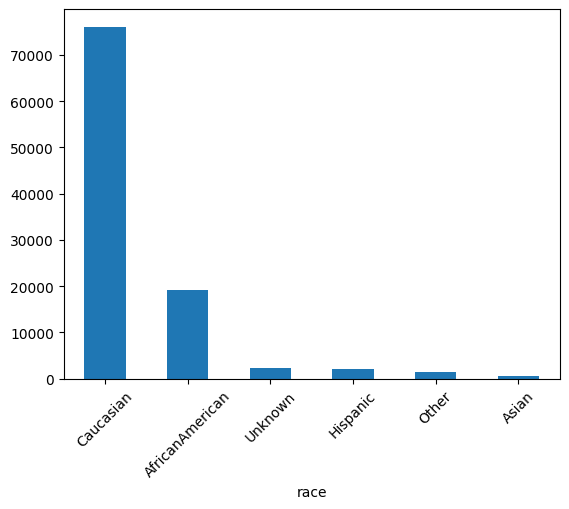

In [ ]:
df["race"].value_counts().plot(kind='bar', rot=45);

In [ ]:
df["gender"].value_counts()

,count
gender,
Female,54708
Male,47055
Unknown/Invalid,3


In [ ]:
df["gender"].value_counts(normalize=True)

,proportion
gender,
Female,0.537586
Male,0.462384
Unknown/Invalid,0.000029


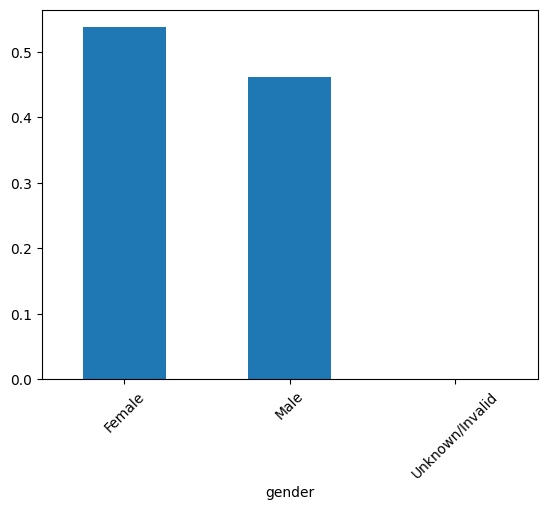

In [ ]:
df["gender"].value_counts(normalize=True).plot(kind='bar', rot=45);

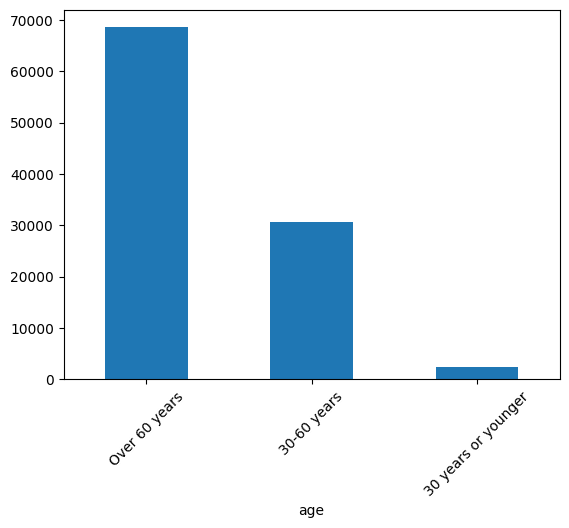

In [ ]:
df["age"].value_counts().plot(kind='bar', rot=45);

**Observaciones**

**Columna race**



**Columna gender**


**Columna age**



**¿Qué decisión tomamos respecto a los grupos con poca representación?**

En nuestro caso, haremos:

*
*

In [ ]:
# drop gender group Unknown/Invalid
df = df.query("gender != 'Unknown/Invalid'")
df.gender.value_counts()

,count
gender,
Female,54708
Male,47055
Unknown/Invalid,0


In [ ]:
# retain the original race as race_all, and merge Asian+Hispanic+Other
df["race_all"] = df["race"]
df["race"] = df["race"].replace({"Asian": "Other", "Hispanic": "Other", "Unknown": "Other"})
df.race.value_counts()
df = df.query("race != 'Other'")

In [ ]:
df.race.value_counts()

,count
race,
Caucasian,76099
AfricanAmerican,19210
Other,0


## 2. Adecuación de la elección de etiqueta (*readmisión dentro de los 30 días*)

### Explorando la elección del label

La clase pasada cuando hablábamos de sesgos de medicion habiamos mencionado los conceptos de  constructyos (Nosotros tenemos ideas o conceptos) y Proxies (elegimos algunas formas concretas de medicion). Por ejemplo, si una persona esta apta para credito es un constructo abstracto que suele operacionalizarse con la medicion de un proxyu como puntaje crediticio.

¿La etiqueta *readmission within 30 days* se condice con nuestro objetivo (identificación de pacientes que podrian beneficiarse de un programa de cuidado)?



### ¿Cómo podemos ver si nuestras asumpciones son válidas?

Lo que sigue esta basado en el trabajo de [Jacobs and Wallach, 2021](https://arxiv.org/abs/1912.05511).

Lo que queremos ver es si las mediciones que realizamos son significativas y útiles para lo que queremos predecir.

* ¿La operacionalización captura todos los aspectos relevantes del constructo que se pretende medir?
* ¿Las medidas parecen plausibles ("Plausible" se refiere a algo atendible, creíble o digno de aplauso. Se usa para describir ideas, excusas o planes que parecen lógicos, viables o razonables, aunque no necesariamente probados)?
* ¿Se correlacionan con otras mediciones del mismo constructo? ¿O varían de maneras que sugieren que la operacionalización puede estar capturando inadvertidamente aspectos de otras construcciones?
* ¿Se cree que las mediciones predictivas de las mediciones de propiedades observables relevantes (y otros constructos teóricos no observables) están relacionadas con el constructo, pero no incorporadas a la operacionalización?


Primero, verifiquemos la tasa a la que los pacientes con diferentes etiquetas readmit_30_days fueron readmitidos en el mes anterior:

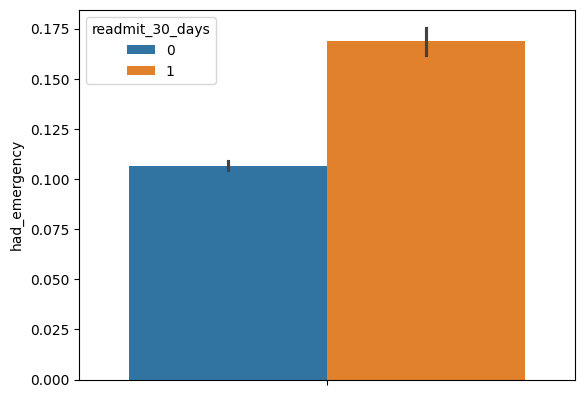

In [ ]:
sns.barplot(y="had_emergency", hue="readmit_30_days", data=df, errorbar=('ci', 95),linestyle='none');

In [ ]:
df[df.readmit_30_days==False].had_emergency.value_counts(normalize=True)

,proportion
had_emergency,
False,0.893262
True,0.106738


In [ ]:
df[df.readmit_30_days==True].had_emergency.value_counts(normalize=True)

,proportion
had_emergency,
False,0.831302
True,0.168698


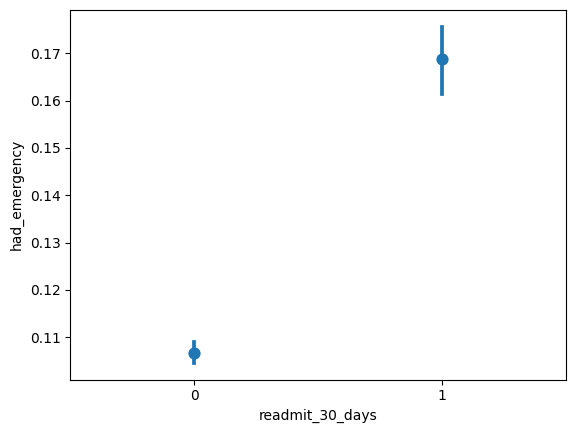

In [ ]:
sns.pointplot(y="had_emergency", x="readmit_30_days", data=df, errorbar=('ci', 95),linestyle='none');

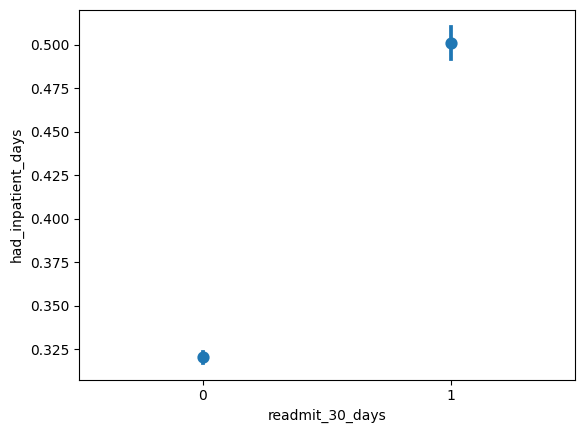

In [ ]:
sns.pointplot(y="had_inpatient_days", x="readmit_30_days", data=df, errorbar=('ci', 95),linestyle='none');

El gráfico muestra que ..

Vemos un patrón similar cuando se utiliza readmit_30_days para predecir la tasa de visitas al hospital (que no son de emergencia) en el año anterior:

## ¿La capacidad de predicción es similar en diferentes grupos raciales? Primero, analicemos qué tan bien predice `readmit_30_days` `had_emergency`:

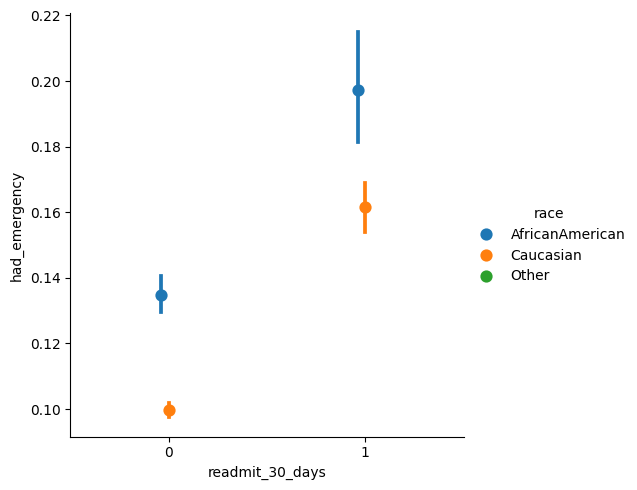

In [ ]:
sns.catplot(y="had_emergency", x="readmit_30_days", hue="race",kind="point",dodge=True, data=df, errorbar=('ci', 95),linestyle='none');

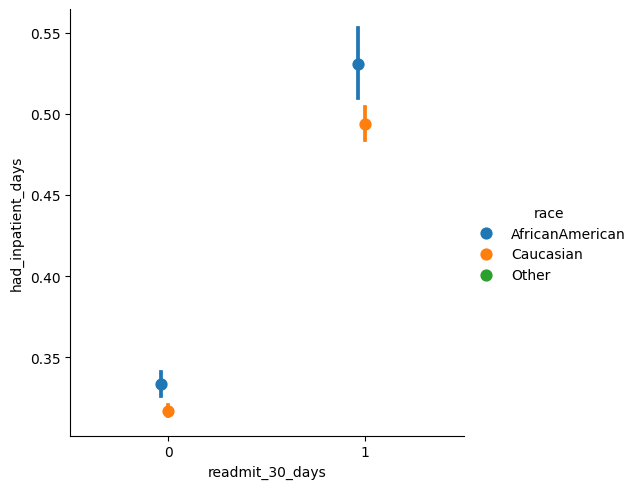

In [ ]:
sns.catplot(y="had_inpatient_days", x="readmit_30_days", hue="race", data=df,
            kind="point", dodge=True,  errorbar=('ci', 95),linestyle='none');

Observaciones:

1.

2.

Veamos ahora que pasa con las revisitas al hospital que no fueron emergencia:

Observamos patrones similares al caso anterior:

1.

2.

En todos los casos, vemos que el reingreso en 30 días predice nuestras dos mediciones de la salud general del paciente.

**Obs**: el análisis también está sacando a la luz el hecho de que los pacientes *Unknown* tienen menos visitas al hospital en el año anterior (tanto de emergencia como de no emergencia) que otros grupos. En la práctica, esta sería una buena razón para contactar a los profesionales de la salud para investigar esta cohorte de pacientes, para asegurarnos de que entendemos por qué existe una diferencia sistemática.

## 3. ¿Las etiqueta están equilibradas?

Ahora que hemos establecido la validez de nuestra etiqueta, verificaremos la frecuencia de sus valores en nuestros datos. La frecuencia de diferentes etiquetas es una característica descriptiva importante en los entornos de clasificación por varias razones:
* algunos algoritmos de clasificación y medidas de performance podrían no funcionar bien con conjuntos de datos con etiquetas desequilibradas
* en entornos de clasificación binaria, nuestra capacidad para evaluar el error a menudo depende del tamaño de la más pequeña de las dos clases (nuevamente, cuanto más pequeña es la muestra, mayor es la incertidumbre en las estimaciones)
* el desequilibrio de etiquetas puede exacerbar los problemas debido al tamaño más pequeño de los grupos en la evaluación de la equidad

Veamos entonces cuántas etiquetas de cada tipo hay:

In [ ]:
df["readmit_30_days"].value_counts()

,count
readmit_30_days,
0,84562
1,10747


Analicemos ahora como varían estas etiquetas respecto a los grupos de interés:

<Axes: xlabel='readmit_30_days', ylabel='race'>

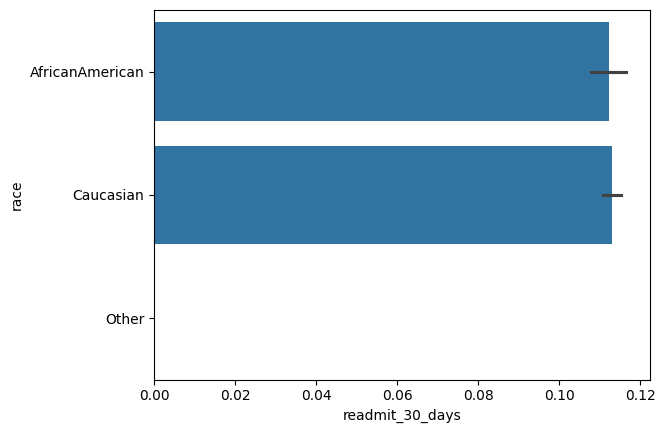

In [ ]:
sns.barplot(x="readmit_30_days",y="race", data=df)

In [ ]:
df.groupby("race")["readmit_30_days"].value_counts()

/tmp/ipykernel_5254/3462532238.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("race")["readmit_30_days"].value_counts()


race             readmit_30_days
AfricanAmerican  0                  17055
                 1                   2155
Caucasian        0                  67507
                 1                   8592
Other            0                      0
                 1                      0
Name: count, dtype: int64

Observamos que:
1.

### Proxies

A continuación investigamos cuáles de los atributos son altamente predictivas de la característica sensible *raza*; estas características se denominan *proxies*.

Si bien en esta clase examinamos cuestiones de equidad a través del **impacto** del modelo de aprendizaje automático en diferentes poblaciones, existen otros conceptos de equidad que buscan analizar cómo el **modelo podría estar usando la información** contenida en las características sensibles y cuáles de los usos de la información están justificados (a menudo usando razonamiento causal). De manera más pragmática, ciertos usos de atributos sensibles (o sustitutos de ellos) podrían ser ilegales en algunos contextos.

Otra razón para comprender los *proxies* es porque podrían explicar por qué vemos diferencias en el impacto en diferentes grupos incluso cuando nuestro modelo no tiene acceso directo a los atributos sensibles.

En esta sección examinamos brevemente la identificación de dichos representantes (pero no entramos en consideraciones legales o de causalidad).

En los Estados Unidos, *Medicare* y *Medicaid* son programas federales y estatales conjuntos para ayudar a las personas a pagar los gastos de atención médica. *Medicare* está disponible para personas mayores de 65 años y personas más jóvenes con enfermedades graves. *Medicaid* está disponible para todas las personas menores de 65 años cuyo ingreso bruto ajustado esté por debajo del umbral federal de pobreza.

¿Son *Medicare* y *Medicaid* **proxies** de los grupos de interés?
Para responder esto, exploremos la relación entre los pacientes que pagaron con *Medicaid* y nuestras características demográficas. Debido a que *Medicaid* está disponible para personas de bajos ingresos y la raza está correlacionada con el nivel socioeconómico en los Estados Unidos, esperamos que exista una relación entre la raza y el pago de *Medicaid*.

<Axes: xlabel='race', ylabel='medicare'>

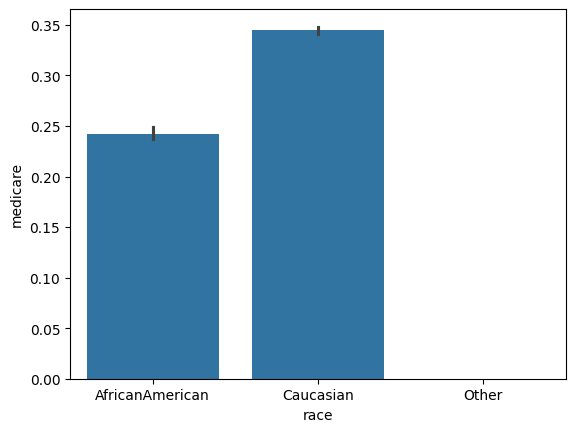

In [ ]:
sns.barplot(y="medicare", x="race", data=df,linestyle='none')

<Axes: xlabel='race', ylabel='medicaid'>

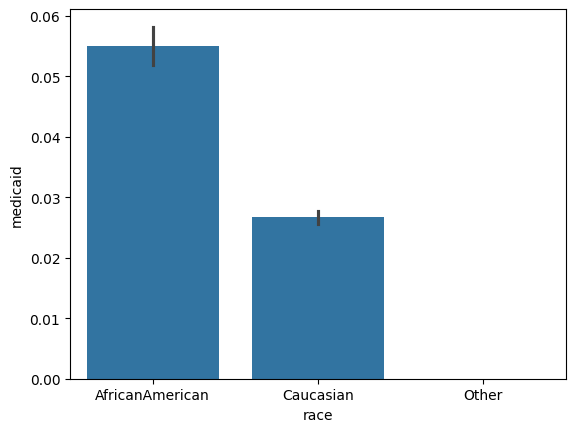

In [ ]:
sns.barplot(y="medicaid", x="race", data=df,linestyle='none')